In [3]:
CELEB_DIR  = '/kaggle/input/datasets/reubensuju/celeb-df-v2'
OUT_DIR    = '/kaggle/working/celeb_frames'

FRAMES_PER_VIDEO = 20
BATCH_SIZE       = 32
NUM_WORKERS      = 2
SEED             = 42
EPOCHS           = 15
LR               = 1e-4

import random, os, time
import numpy as np
import torch
import torch.nn as nn

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [4]:
import cv2
import urllib.request
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# Download haar cascade for face detection
cascade_path = '/kaggle/working/haarcascade_frontalface_default.xml'
if not os.path.exists(cascade_path):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml',
        cascade_path
    )
face_cascade = cv2.CascadeClassifier(cascade_path)

def get_face_box(image_pil):
    img_rgb  = np.array(image_pil.convert('RGB'))
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    faces    = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1,
                                             minNeighbors=5, minSize=(30, 30))
    if len(faces) == 0:
        return None
    return [[x, y, x+w, y+h] for (x, y, w, h) in faces]

print('Imports done')

Imports done


In [5]:
def extract_frames(video_path, out_dir, n_frames=20):
    os.makedirs(out_dir, exist_ok=True)
    cap    = cv2.VideoCapture(video_path)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    stride = max(total // n_frames, 1)
    saved  = 0
    for i in range(n_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * stride)
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imwrite(os.path.join(out_dir, f'frame_{i:04d}.jpg'), frame)
        saved += 1
    cap.release()
    return saved

# Read official test split
test_videos = set()
with open(os.path.join(CELEB_DIR, 'List_of_testing_videos.txt')) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            test_videos.add(parts[1])
print(f'Official test videos: {len(test_videos)}')

# Extract frames
for label, folder in [('real', 'Celeb-real'),
                       ('real', 'YouTube-real'),
                       ('fake', 'Celeb-synthesis')]:
    src_dir = os.path.join(CELEB_DIR, folder)
    for vid in os.listdir(src_dir):
        if not vid.endswith('.mp4'):
            continue
        rel_path = f'{folder}/{vid}'
        split    = 'test' if rel_path in test_videos else 'train'
        out_dir  = f'{OUT_DIR}/{split}/{label}/{Path(vid).stem}'
        if not os.path.exists(out_dir):
            extract_frames(os.path.join(src_dir, vid), out_dir, FRAMES_PER_VIDEO)
    print(f'{folder} done')

# Count
for split in ['train', 'test']:
    for label in ['real', 'fake']:
        path = f'{OUT_DIR}/{split}/{label}'
        if os.path.exists(path):
            count = sum(len(os.listdir(f'{path}/{d}')) for d in os.listdir(path))
            print(f'{split}/{label}: {count} frames')

Official test videos: 518
Celeb-real done
YouTube-real done
Celeb-synthesis done
train/real: 14221 frames
train/fake: 105980 frames
test/real: 3560 frames
test/fake: 6800 frames


In [6]:
class CelebDFDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.transform = transform
        self.samples   = []
        for label, cls in enumerate(['real', 'fake']):  # 0=real, 1=fake
            folder = Path(root_dir) / split / cls
            if not folder.exists():
                print(f'Warning: {folder} not found')
                continue
            for vid_dir in folder.iterdir():
                for img_path in vid_dir.glob('*.jpg'):
                    self.samples.append((str(img_path), label))
        random.shuffle(self.samples)
        real_n = sum(1 for _, l in self.samples if l == 0)
        fake_n = sum(1 for _, l in self.samples if l == 1)
        print(f'[{split}] real={real_n} fake={fake_n} total={len(self.samples)}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = CelebDFDataset(OUT_DIR, split='train', transform=train_transform)
test_dataset  = CelebDFDataset(OUT_DIR, split='test',  transform=val_transform)

[train] real=14221 fake=105980 total=120201
[test] real=3560 fake=6800 total=10360


In [7]:
real_samples = [(p, l) for p, l in train_dataset.samples if l == 0]
fake_samples = [(p, l) for p, l in train_dataset.samples if l == 1]

random.seed(SEED)
fake_balanced = random.sample(fake_samples, len(real_samples))
balanced      = real_samples + fake_balanced
random.shuffle(balanced)

train_dataset.samples = balanced
print(f'Balanced train — real: {len(real_samples)} fake: {len(fake_balanced)} total: {len(balanced)}')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Balanced train — real: 14221 fake: 14221 total: 28442
Train batches: 889 | Test batches: 324


In [8]:
def build_model():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    return model

model = build_model().to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Model ready | Trainable: {trainable:,} / {total:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 130MB/s] 


Model ready | Trainable: 4,010,110 / 4,010,110


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                        patience=3, factor=0.5)
best_acc, best_state = 0.0, None

print(f"\n{'='*60}")
print(f"  Training on Celeb-DF v2 | {EPOCHS} epochs | LR={LR}")
print(f"{'='*60}")

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0                         = time.time()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    model.eval()
    val_correct, val_total = 0, 0
    real_correct, real_n   = 0, 0
    fake_correct, fake_n   = 0, 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds         = model(imgs).argmax(1)
            val_correct  += (preds == labels).sum().item()
            val_total    += labels.size(0)
            real_correct += ((preds == labels) & (labels == 0)).sum().item()
            real_n       += (labels == 0).sum().item()
            fake_correct += ((preds == labels) & (labels == 1)).sum().item()
            fake_n       += (labels == 1).sum().item()

    val_acc = val_correct / val_total
    scheduler.step(val_acc)

    print(f'Epoch {epoch}/{EPOCHS} | '
          f'Train Loss: {total_loss/total:.4f} Acc: {correct/total:.4f} | '
          f'Val Acc: {val_acc:.4f} '
          f'(Real: {real_correct/real_n*100:.1f}% Fake: {fake_correct/fake_n*100:.1f}%) | '
          f'{time.time()-t0:.0f}s')

    if val_acc > best_acc:
        best_acc   = val_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

print(f'\nBest Val Acc: {best_acc*100:.2f}%')


  Training on Celeb-DF v2 | 15 epochs | LR=0.0001
Epoch 1/15 | Train Loss: 0.3678 Acc: 0.8241 | Val Acc: 0.8180 (Real: 81.5% Fake: 81.9%) | 181s
Epoch 2/15 | Train Loss: 0.1934 Acc: 0.9192 | Val Acc: 0.8645 (Real: 71.3% Fake: 94.4%) | 187s
Epoch 3/15 | Train Loss: 0.1399 Acc: 0.9434 | Val Acc: 0.8771 (Real: 78.2% Fake: 92.7%) | 187s
Epoch 4/15 | Train Loss: 0.1113 Acc: 0.9554 | Val Acc: 0.8771 (Real: 75.1% Fake: 94.3%) | 187s
Epoch 5/15 | Train Loss: 0.0914 Acc: 0.9635 | Val Acc: 0.8830 (Real: 77.1% Fake: 94.2%) | 188s
Epoch 6/15 | Train Loss: 0.0771 Acc: 0.9706 | Val Acc: 0.8846 (Real: 79.7% Fake: 93.0%) | 187s
Epoch 7/15 | Train Loss: 0.0645 Acc: 0.9754 | Val Acc: 0.8832 (Real: 79.1% Fake: 93.1%) | 188s
Epoch 8/15 | Train Loss: 0.0596 Acc: 0.9783 | Val Acc: 0.8918 (Real: 82.3% Fake: 92.8%) | 188s
Epoch 9/15 | Train Loss: 0.0507 Acc: 0.9823 | Val Acc: 0.8950 (Real: 80.9% Fake: 94.0%) | 187s
Epoch 10/15 | Train Loss: 0.0482 Acc: 0.9821 | Val Acc: 0.8861 (Real: 81.0% Fake: 92.6%) | 186

In [10]:
model.load_state_dict(best_state)
torch.save(model.state_dict(), '/kaggle/working/deepfake_celebdf.pth')
print(f'Saved → /kaggle/working/deepfake_celebdf.pth')
print(f'Best Val Acc: {best_acc*100:.2f}%')

Saved → /kaggle/working/deepfake_celebdf.pth
Best Val Acc: 90.29%


In [11]:
!pip install grad-cam -q

from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model.eval()

def get_heatmap(image_pil):
    tensor       = val_transform(image_pil).unsqueeze(0).to(device)
    target_layer = [model.features[-3]]
    cam          = EigenCAM(model=model, target_layers=target_layer)
    return cam(input_tensor=tensor, targets=[ClassifierOutputTarget(1)])[0]

def pointing_game(image_pil, heatmap):
    boxes = get_face_box(image_pil)
    if boxes is None:
        return None
    h, w            = np.array(image_pil).shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    peak_y, peak_x  = np.unravel_index(heatmap_resized.argmax(), heatmap_resized.shape)
    for x1, y1, x2, y2 in boxes:
        if x1 <= peak_x <= x2 and y1 <= peak_y <= y2:
            return 1
    return 0

def mask_iou(image_pil, heatmap, threshold=0.6):
    boxes = get_face_box(image_pil)
    if boxes is None:
        return None
    h, w            = np.array(image_pil).shape[:2]
    gt_mask         = np.zeros((h, w), dtype=np.uint8)
    for x1, y1, x2, y2 in boxes:
        gt_mask[max(0,y1):min(h,y2), max(0,x1):min(w,x2)] = 1
    heatmap_resized = cv2.resize(heatmap, (w, h))
    pred_mask       = (heatmap_resized > threshold).astype(np.uint8)
    intersection    = np.logical_and(pred_mask, gt_mask).sum()
    union           = np.logical_or(pred_mask, gt_mask).sum()
    return intersection / union if union > 0 else 0.0

fake_paths  = [p for p, l in test_dataset.samples if l == 1][:200]
pg_scores, iou_scores = [], []

for path in fake_paths:
    image   = Image.open(path).convert('RGB')
    heatmap = get_heatmap(image)
    pg      = pointing_game(image, heatmap)
    iou     = mask_iou(image, heatmap)
    if pg  is not None: pg_scores.append(pg)
    if iou is not None: iou_scores.append(iou)

print(f'Pointing Game Accuracy : {np.mean(pg_scores)*100:.2f}%')
print(f'Mean IoU (face proxy)  : {np.mean(iou_scores):.4f}')
print(f'Samples evaluated      : {len(pg_scores)}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 72.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda

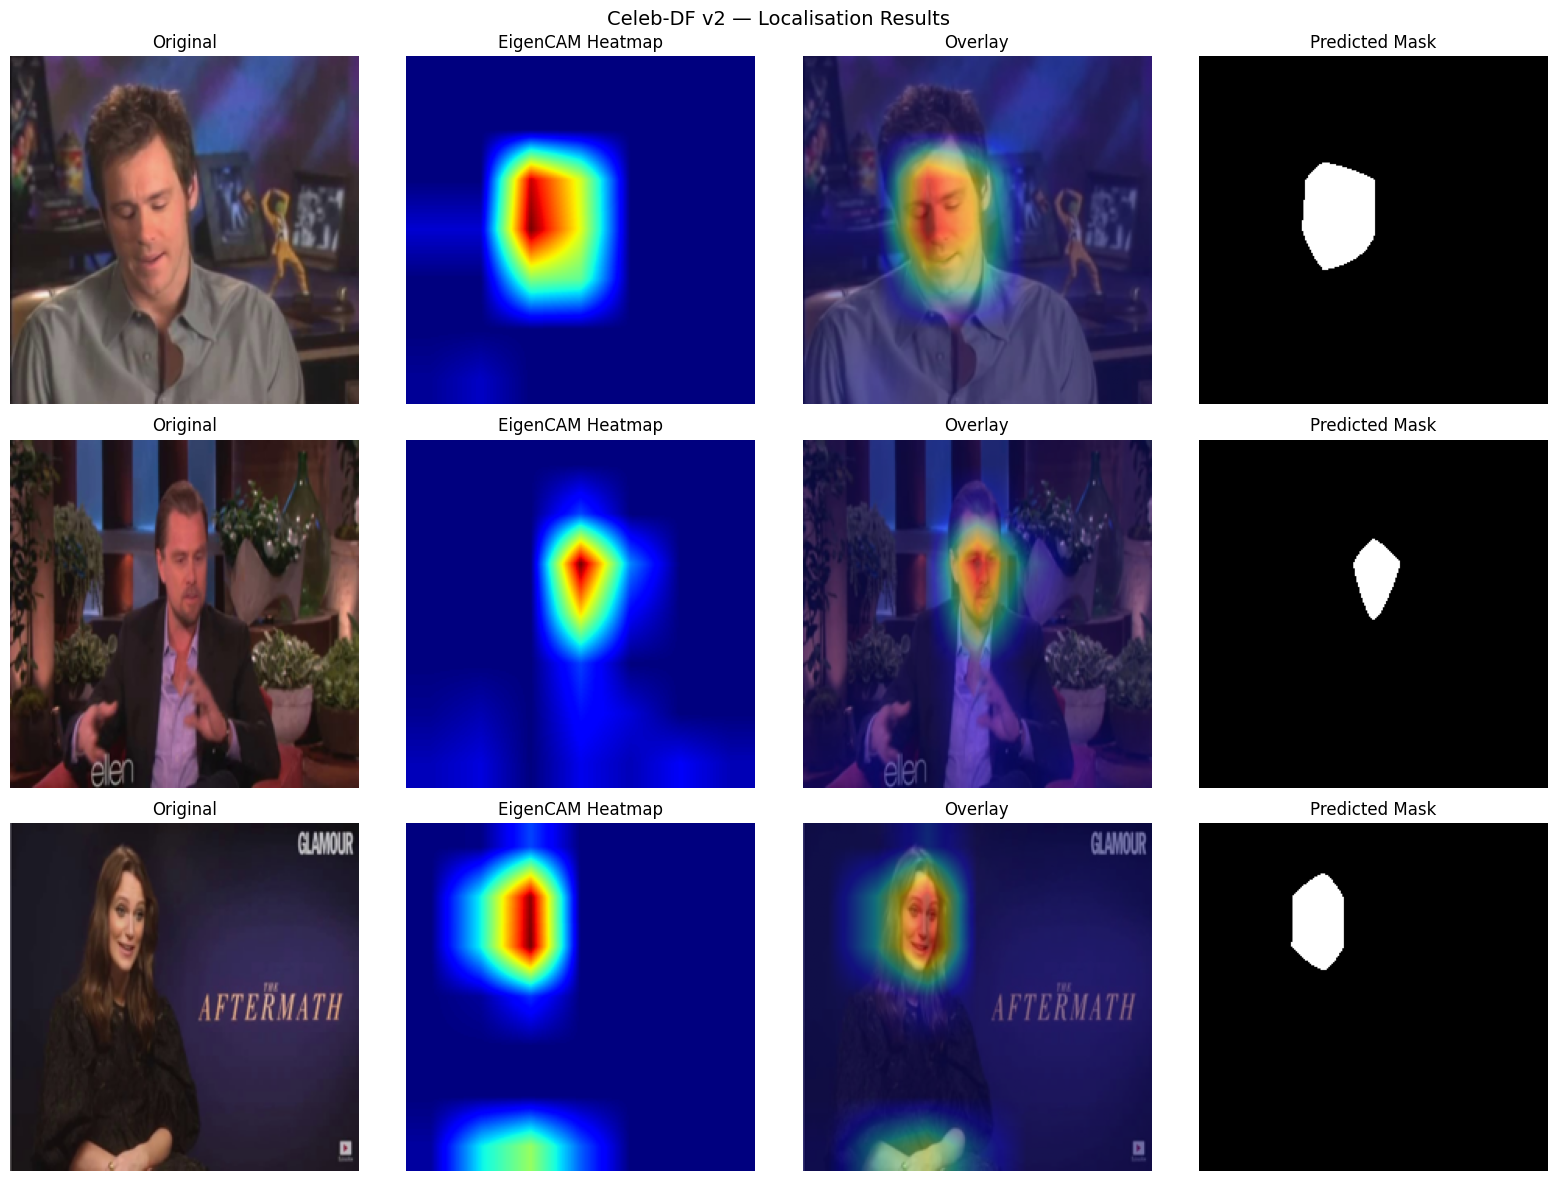

Saved → /kaggle/working/localisation_results.png


In [12]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
sample_paths = [p for p, l in test_dataset.samples if l == 1][:3]

for row, path in enumerate(sample_paths):
    image   = Image.open(path).convert('RGB').resize((224, 224))
    img_arr = np.array(image) / 255.0
    heatmap = get_heatmap(image)
    hmap_r  = cv2.resize(heatmap, (224, 224))

    axes[row][0].imshow(image)
    axes[row][0].set_title('Original')
    axes[row][1].imshow(hmap_r, cmap='jet')
    axes[row][1].set_title('EigenCAM Heatmap')
    overlay = img_arr * 0.6 + plt.cm.jet(hmap_r)[:, :, :3] * 0.4
    axes[row][2].imshow(overlay)
    axes[row][2].set_title('Overlay')
    axes[row][3].imshow((hmap_r > 0.6).astype(np.uint8), cmap='gray')
    axes[row][3].set_title('Predicted Mask')
    for ax in axes[row]: ax.axis('off')

plt.suptitle('Celeb-DF v2 — Localisation Results', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/localisation_results.png', dpi=150)
plt.show()
print('Saved → /kaggle/working/localisation_results.png')